In [ ]:
def heat_map_MSigDB_Hallmark():
    import gseapy as gp
    import pandas as pd
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Read delta data to get tissue names
    delta_data = pd.read_csv('/shares/sinha/epallapotu/blood_expression_project/all_tissues_delta_scores.tsv', sep='\t')
    unique_tissues = delta_data["tissue"].unique()

    # Create a dictionary to store NES scores
    combined_nes_scores = {}

    for tissue in unique_tissues:
        file_path = f"/shares/sinha/epallapotu/blood_expression_project/{tissue}_analysis_results/{tissue}_correlation_results.csv"
        df = pd.read_csv(file_path)

        df_new = df.drop(['P_value', 'Name'], axis=1)
        df_new = df_new.dropna(subset=['Pearson', 'Description']).reset_index(drop=True)
        df_sorted = df_new.sort_values(by='Pearson', ascending=False).copy()
        df_sorted['Pearson'] = pd.to_numeric(df_sorted['Pearson'], errors='coerce')
        df_sorted = df_sorted.dropna(subset=['Pearson', 'Description'])
        df_sorted['Pearson'] = df_sorted['Pearson'].astype(np.float64)
        df_sorted.rename(columns={'Pearson': 'score', 'Description': 'gene_name'}, inplace=True)
        df_sorted['gene_name'] = df_sorted['gene_name'].str.upper()
        rnk_df = df_sorted[['gene_name', 'score']]

        enrichment_results = gp.prerank(
            rnk=rnk_df,
            gene_sets="h.all.v2025.1.Hs.symbols.gmt",
            outdir=None,
            seed=42
        )
        enrichment_df = pd.DataFrame(enrichment_results.results).transpose()

        # Get NES scores
        nes_scores = pd.to_numeric(enrichment_df['nes'], errors='coerce')
        combined_nes_scores[tissue] = nes_scores

    # Combine all NES scores into a single DataFrame
    heatmap_df = pd.DataFrame(combined_nes_scores)

    # Optional: sort rows and/or columns if needed
    heatmap_df = heatmap_df.sort_index()

    from scipy.cluster.hierarchy import linkage, leaves_list
    from scipy.spatial.distance import pdist

    # Cluster rows (pathways)
    row_linkage = linkage(pdist(heatmap_df.fillna(0)), method='average')
    row_order = leaves_list(row_linkage)

    # Cluster columns (tissues)
    col_linkage = linkage(pdist(heatmap_df.fillna(0).T), method='average')
    col_order = leaves_list(col_linkage)

    # Reorder heatmap_df
    ordered_df = heatmap_df.iloc[row_order, :].iloc[:, col_order]

    # Plot heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        ordered_df,
        cmap='RdBu_r',
        center=0,
        annot=False,
        xticklabels=True,
        yticklabels=True,
        cbar_kws={'label': 'NES Score'}
    )
    plt.xticks(rotation=45, ha='right')
    plt.title(" MSigDB NES Heatmap")
    plt.tight_layout()
    plt.show()

In [ ]:
heat_map_MSigDB_Hallmark()

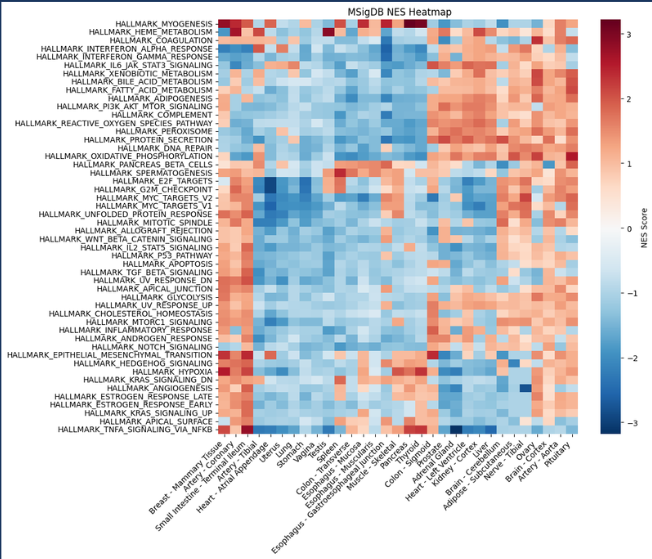

Kegg Pathways:

In [ ]:
#def heat_map_Kegg():
import gseapy  as gp
import pandas as pd
import numpy as np
#delta_data = pd.read_csv('/shares/sinha/epallapotu/blood_expression_project/all_tissues_delta_scores.tsv', sep='\t')
#unique_tissues = delta_data["tissue"].unique()
#for tissue in unique_tissues:
tissue="Ovary"
file_path= f"/shares/sinha/epallapotu/blood_expression_project/{tissue}_analysis_results/{tissue}_correlation_results.csv"
df = pd.read_csv(file_path)
df_new = df.drop(['P_value', 'Name'], axis=1)
df_new = df_new.dropna(subset=['Pearson', 'Description']).reset_index(drop=True)
df_sorted = df_new.sort_values(by='Pearson', ascending=False)
df_sorted = df_sorted.copy()
# Convert the 'score' column to numeric, coercing errors to NaN
df_sorted['Pearson'] = pd.to_numeric(df_sorted['Pearson'], errors='coerce')
# Drop rows where 'score' is NaN or 'gene_name' is NaN
df_sorted = df_sorted.dropna(subset=['Pearson', 'Description'])
# Ensure the 'score' column is of type float64
df_sorted['Pearson'] = df_sorted['Pearson'].astype(np.float64)
df_sorted.rename(columns={'Pearson': 'score', 'Description': 'gene_name'}, inplace=True)
df_sorted['gene_name'] = df_sorted['gene_name'].str.upper()
rnk_df = df_sorted[['gene_name', 'score']]
enrichment_results = gp.prerank(
    rnk=rnk_df ,  # DataFrame with gene names and correlation scores
    gene_sets="KEGG_2021_Human",
    outdir=None,
    seed=42
)
enrichment_dataframe=pd.DataFrame(enrichment_results.results)
enrichment_dataframe=enrichment_dataframe.transpose()
# Extract NES values for heatmap
nes_score = enrichment_dataframe['nes']
# Convert object dtype to numeric, handling any problematic values
nes_score_clean = pd.to_numeric(nes_score, errors='coerce')

# Check if conversion worked
print("New dtype:", nes_score_clean.dtype)
print("Any NaN values after conversion:", nes_score_clean.isna().sum())

# If there are NaN values, see which ones they are
if nes_score_clean.isna().sum() > 0:
    print("NaN locations:")
    print(nes_score[nes_score_clean.isna()])
nes_score_clean=nes_score_clean.sort_values(ascending=False)
import matplotlib.pyplot as plt
import seaborn as sns
# Remove any NaN values that might have been created
nes_score_final = nes_score_clean.dropna()

# Create the matrix for heatmap
nes_matrix = nes_score_final.values.reshape(-1, 1)
pathway_names = nes_score_final.index

# Plot the heatmap
plt.figure(figsize=(6, 36))
sns.heatmap(nes_matrix,
        yticklabels=pathway_names,
        xticklabels=[f'{tissue}'],
        annot=False, cmap='RdBu_r', center=0,
        fmt=".2f", cbar_kws={'label': 'NES Score'})
plt.title('Kegg Pathway Enrichment Score (NES)')
plt.ylabel('Pathways')
plt.tight_layout()
plt.show()

In [ ]:
def heat_map_Kegg():
    import gseapy as gp
    import pandas as pd
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Read delta data to get tissue names
    delta_data = pd.read_csv('/shares/sinha/epallapotu/blood_expression_project/all_tissues_delta_scores.tsv', sep='\t')
    unique_tissues = delta_data["tissue"].unique()

    # Create a dictionary to store NES scores
    combined_nes_scores = {}

    for tissue in unique_tissues:
        file_path = f"/shares/sinha/epallapotu/blood_expression_project/{tissue}_analysis_results/{tissue}_correlation_results.csv"
        df = pd.read_csv(file_path)

        df_new = df.drop(['P_value', 'Name'], axis=1)
        df_new = df_new.dropna(subset=['Pearson', 'Description']).reset_index(drop=True)
        df_sorted = df_new.sort_values(by='Pearson', ascending=False).copy()
        df_sorted['Pearson'] = pd.to_numeric(df_sorted['Pearson'], errors='coerce')
        df_sorted = df_sorted.dropna(subset=['Pearson', 'Description'])
        df_sorted['Pearson'] = df_sorted['Pearson'].astype(np.float64)
        df_sorted.rename(columns={'Pearson': 'score', 'Description': 'gene_name'}, inplace=True)
        df_sorted['gene_name'] = df_sorted['gene_name'].str.upper()
        rnk_df = df_sorted[['gene_name', 'score']]

        enrichment_results = gp.prerank(
            rnk=rnk_df,
            gene_sets="KEGG_2021_Human",
            outdir=None,
            seed=42
        )
        enrichment_df = pd.DataFrame(enrichment_results.results).transpose()

        # Get NES scores
        nes_scores = pd.to_numeric(enrichment_df['nes'], errors='coerce')
        combined_nes_scores[tissue] = nes_scores

 # Combine all NES scores into a single DataFrame
    heatmap_df = pd.DataFrame(combined_nes_scores)

    # Optional: sort rows and/or columns if needed
    heatmap_df = heatmap_df.sort_index()

    from scipy.cluster.hierarchy import linkage, leaves_list
    from scipy.spatial.distance import pdist

    # Cluster rows (pathways)
    row_linkage = linkage(pdist(heatmap_df.fillna(0)), method='average')
    row_order = leaves_list(row_linkage)

    # Cluster columns (tissues)
    col_linkage = linkage(pdist(heatmap_df.fillna(0).T), method='average')
    col_order = leaves_list(col_linkage)

    # Reorder heatmap_df
    ordered_df = heatmap_df.iloc[row_order, :].iloc[:, col_order]

    # Plot heatmap
    plt.figure(figsize=(12, 36))
    sns.heatmap(
        ordered_df,
        cmap='RdBu_r',
        center=0,
        annot=False,
        xticklabels=True,
        yticklabels=True,
        cbar_kws={'label': 'NES Score'}
    )
    plt.xticks(rotation=45, ha='right')
    plt.title(" Kegg NES Heatmap")
    plt.tight_layout()
    plt.show()


In [ ]:
heat_map_Kegg()

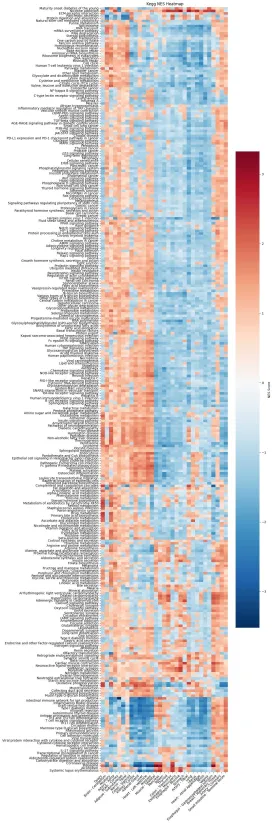

In [ ]:
gp.get_library_name()

Reactome

In [ ]:
Reactome_Pathways_2024

In [ ]:
def heat_map_Reactome():
    import gseapy as gp
    import pandas as pd
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt
    from scipy.cluster.hierarchy import linkage, leaves_list
    from scipy.spatial.distance import pdist
    import os

    # # Define tissues manually
    # delta_data = pd.read_csv('/shares/sinha/epallapotu/blood_expression_project/all_tissues_delta_scores.tsv', sep='\t')
    # unique_tissues = delta_data["tissue"].unique()

    # combined_nes_scores = {}
    # pathway_names = set()

    # for tissue in unique_tissues:
    #     file_path = f"/shares/sinha/epallapotu/blood_expression_project/{tissue}_analysis_results/{tissue}_correlation_results.csv"
    #     df = pd.read_csv(file_path)

    #     df_new = df.drop(['P_value', 'Name'], axis=1, errors='ignore')
    #     df_new = df_new.dropna(subset=['Pearson', 'Description']).reset_index(drop=True)
    #     df_new['Pearson'] = pd.to_numeric(df_new['Pearson'], errors='coerce')
    #     df_new = df_new.dropna(subset=['Pearson'])

    #     df_new.rename(columns={'Pearson': 'score', 'Description': 'gene_name'}, inplace=True)
    #     df_new['gene_name'] = df_new['gene_name'].str.upper()
    #     rnk_df = df_new[['gene_name', 'score']]

    #     enrichment_results = gp.prerank(
    #         rnk=rnk_df,
    #         gene_sets="Reactome_Pathways_2024",
    #         outdir=None,
    #         seed=42
    #     )

    #     enrichment_df = pd.DataFrame(enrichment_results.results).transpose().reset_index()
    #     enrichment_df.rename(columns={'index': 'Pathway', 'nes': 'NES'}, inplace=True)
    #     enrichment_df = enrichment_df[['Pathway', 'NES']].dropna()

    #     pathway_names.update(enrichment_df['Pathway'].tolist())

    #     enrichment_df.set_index('Pathway', inplace=True)
    #     combined_nes_scores[tissue] = enrichment_df['NES']

    # # Combine into DataFrame
    # heatmap_df = pd.DataFrame(combined_nes_scores)

    # # Save full NES matrix if needed
    # os.makedirs("all_tissue_results", exist_ok=True)
    # heatmap_df.to_csv("all_tissue_results/heatmap_reactome.csv")
    delta_data = pd.read_csv('/shares/sinha/epallapotu/blood_expression_project/all_tissues_delta_scores.tsv', sep='\t')
    unique_tissues = delta_data["tissue"].unique()
    heatmap_df = pd.read_csv("all_tissue_results/heatmap_reactome.csv", index_col=0)

    # Identify top pathways
    specific_pathways = set()
    for tissue in unique_tissues:
        if tissue in heatmap_df:
            top_pathways = heatmap_df[tissue].dropna().sort_values(ascending=False).head(10).index.tolist()
            specific_pathways.update(top_pathways)

    # Filter and clean
    filtered_df = heatmap_df.loc[heatmap_df.index.intersection(specific_pathways)]
    filtered_df = filtered_df.apply(pd.to_numeric, errors='coerce')  # Ensure numeric

    # Clustering
    row_linkage = linkage(pdist(filtered_df.fillna(0)), method='average')
    row_order = leaves_list(row_linkage)

    col_linkage = linkage(pdist(filtered_df.fillna(0).T), method='average')
    col_order = leaves_list(col_linkage)

    # Apply ordering
    ordered_df = filtered_df.iloc[row_order, :].iloc[:, col_order]
    ordered_df = ordered_df.apply(pd.to_numeric, errors='coerce').fillna(0)

    # Plot
    plt.figure(figsize=(20, 36))  # Width x Height in inches
    sns.heatmap(
        ordered_df,
        cmap='RdBu_r',
        center=0,
        annot=False,
        xticklabels=True,
        yticklabels=True,
        cbar_kws={'label': 'NES Score'}
    )
    plt.xticks(rotation=45, ha='right')
    plt.title("Reactome Pathways NES Heatmap")
    plt.tight_layout()
    plt.show()

    return ordered_df


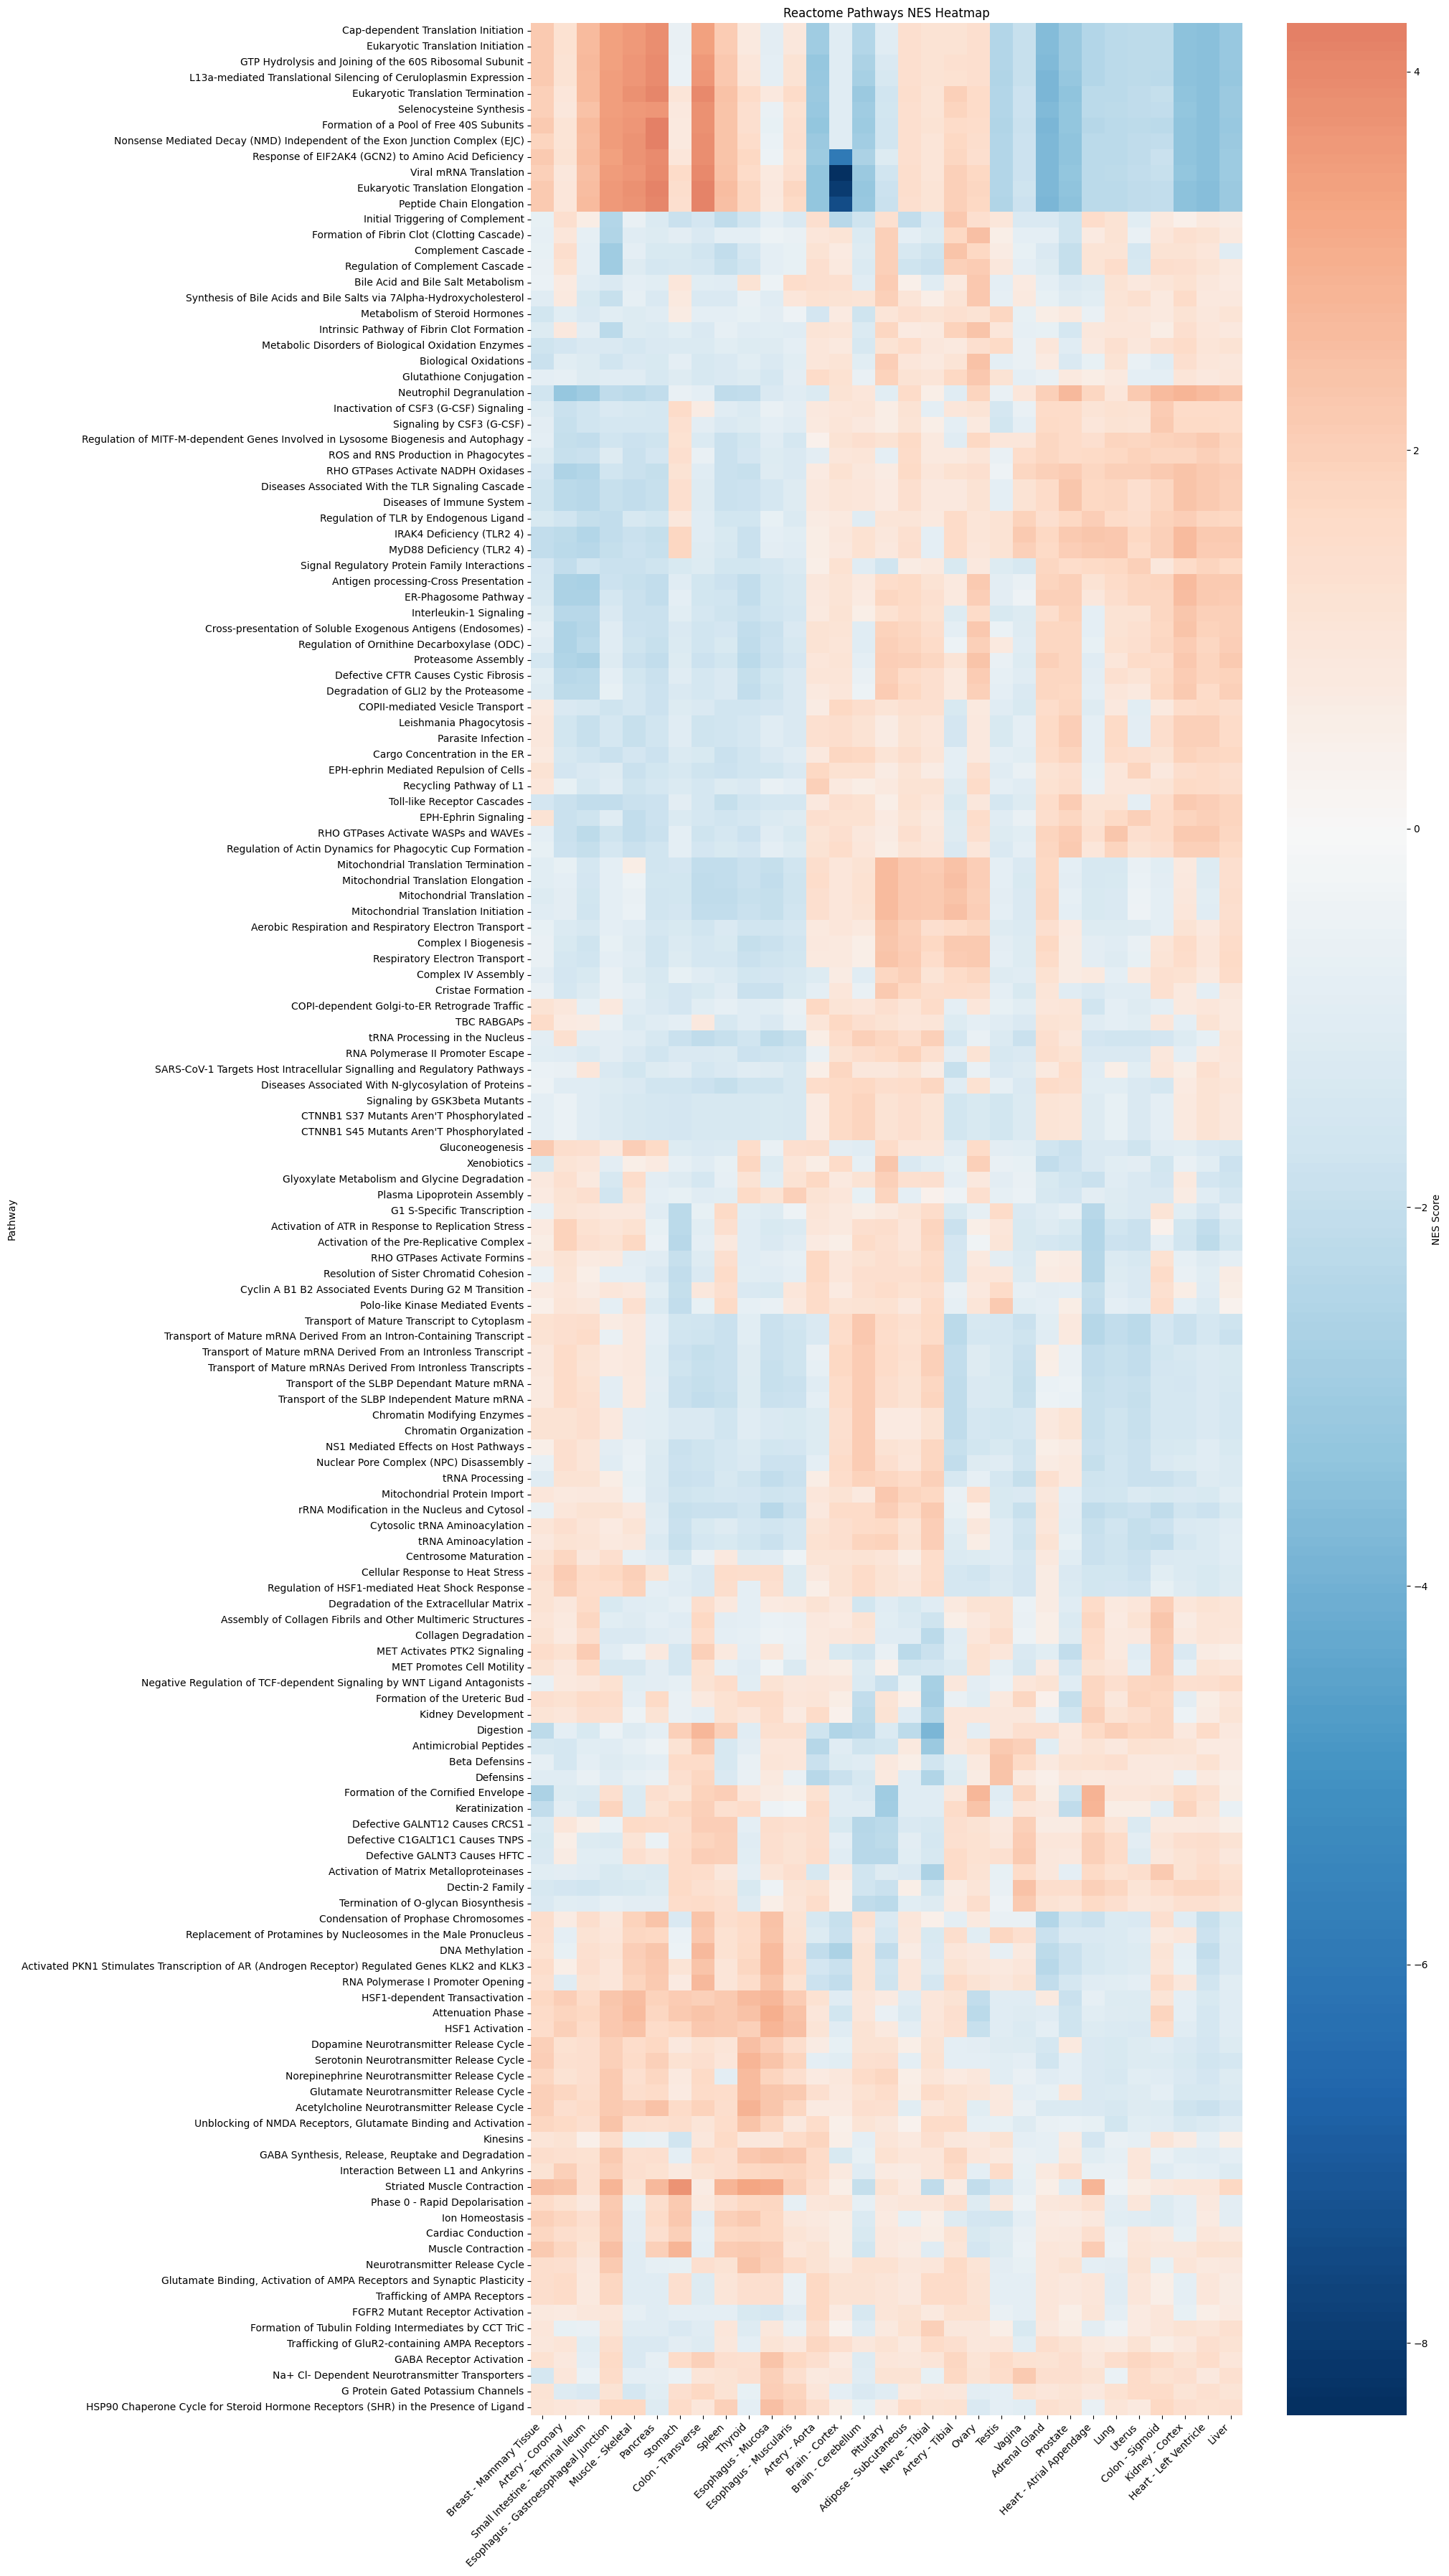

,Breast - Mammary Tissue,Artery - Coronary,Small Intestine - Terminal Ileum,Esophagus - Gastroesophageal Junction,Muscle - Skeletal,Pancreas,Stomach,Colon - Transverse,Spleen,Thyroid,...,Vagina,Adrenal Gland,Prostate,Heart - Atrial Appendage,Lung,Uterus,Colon - Sigmoid,Kidney - Cortex,Heart - Left Ventricle,Liver
Pathway,,,,,,,,,,,,,,,,,,,,,
Cap-dependent Translation Initiation,2.156772,1.248493,2.671829,3.412454,3.608110,3.881351,-0.674603,3.404742,2.117240,0.787850,...,-1.955208,-3.626994,-3.123022,-2.427654,-2.284530,-2.205089,-2.204851,-3.401157,-3.454764,-3.157993
Eukaryotic Translation Initiation,2.156772,1.248493,2.671829,3.412454,3.608110,3.881351,-0.674603,3.404742,2.117240,0.787850,...,-1.955208,-3.626994,-3.123022,-2.427654,-2.284530,-2.205089,-2.204851,-3.401157,-3.454764,-3.157993
GTP Hydrolysis and Joining of the 60S Ribosomal Subunit,2.149055,1.195811,2.680745,3.464159,3.696920,3.923510,-0.575277,3.614668,2.263266,1.042408,...,-1.947149,-3.731120,-3.143455,-2.427399,-2.288831,-2.191612,-2.181987,-3.413338,-3.469171,-3.162397
L13a-mediated Translational Silencing of Ceruloplasmin Expression,2.148291,1.178642,2.675226,3.492882,3.673190,3.952180,-0.580244,3.670523,2.261080,1.075451,...,-1.944243,-3.792662,-3.222799,-2.444487,-2.292495,-2.209609,-2.223372,-3.441992,-3.524890,-3.199437
Eukaryotic Translation Termination,1.947960,1.015413,2.591457,3.510291,3.803966,4.092033,1.076803,4.005000,2.444428,1.545326,...,-1.789663,-3.824602,-3.361854,-2.223275,-2.212032,-2.144176,-2.006815,-3.371231,-3.491743,-3.114189
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Trafficking of GluR2-containing AMPA Receptors,0.908720,1.083856,-0.959476,1.483334,-1.249330,-1.255393,-0.878254,-1.109823,0.906876,-0.808428,...,-0.949539,1.470308,1.151446,0.802931,0.693121,1.203828,0.609355,0.883149,1.358659,1.228469
GABA Receptor Activation,1.283020,0.862209,-0.799981,1.679662,-1.277160,-0.742020,1.582871,1.962350,1.358033,1.309542,...,1.267868,1.158991,1.371510,0.924033,1.462102,1.755338,1.583886,1.221597,1.492156,1.034205
Na+ Cl- Dependent Neurotransmitter Transporters,-1.446990,1.005923,-0.568090,1.580641,-0.869410,-0.796323,-0.569108,1.080681,1.148178,1.406213,...,2.147201,1.386536,1.353492,1.180815,-0.581679,1.632223,1.249850,1.361648,0.875386,1.337927


In [ ]:
heat_map_Reactome()

Wiki Pathways: WikiPathways_2024_Human

In [ ]:
def heat_map_Wiki():
    import gseapy as gp
    import pandas as pd
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt
    from scipy.cluster.hierarchy import linkage, leaves_list
    from scipy.spatial.distance import pdist
    import os

    # Define tissues manually
    delta_data = pd.read_csv('/shares/sinha/epallapotu/blood_expression_project/all_tissues_delta_scores.tsv', sep='\t')
    unique_tissues = delta_data["tissue"].unique()

    combined_nes_scores = {}
    pathway_names = set()

    for tissue in unique_tissues:
        file_path = f"/shares/sinha/epallapotu/blood_expression_project/{tissue}_analysis_results/{tissue}_correlation_results.csv"
        df = pd.read_csv(file_path)

        df_new = df.drop(['P_value', 'Name'], axis=1, errors='ignore')
        df_new = df_new.dropna(subset=['Pearson', 'Description']).reset_index(drop=True)
        df_new['Pearson'] = pd.to_numeric(df_new['Pearson'], errors='coerce')
        df_new = df_new.dropna(subset=['Pearson'])

        df_new.rename(columns={'Pearson': 'score', 'Description': 'gene_name'}, inplace=True)
        df_new['gene_name'] = df_new['gene_name'].str.upper()
        rnk_df = df_new[['gene_name', 'score']]

        enrichment_results = gp.prerank(
            rnk=rnk_df,
            gene_sets="WikiPathways_2024_Human",
            outdir=None,
            seed=42
        )

        enrichment_df = pd.DataFrame(enrichment_results.results).transpose().reset_index()
        enrichment_df.rename(columns={'index': 'Pathway', 'nes': 'NES'}, inplace=True)
        enrichment_df = enrichment_df[['Pathway', 'NES']].dropna()

        pathway_names.update(enrichment_df['Pathway'].tolist())

        enrichment_df.set_index('Pathway', inplace=True)
        combined_nes_scores[tissue] = enrichment_df['NES']

    # Combine into DataFrame
    heatmap_df = pd.DataFrame(combined_nes_scores)

    # Save full NES matrix if needed
    os.makedirs("all_tissue_results", exist_ok=True)
    heatmap_df.to_csv("all_tissue_results/heatmap_wiki.csv")
    # delta_data = pd.read_csv('/shares/sinha/epallapotu/blood_expression_project/all_tissues_delta_scores.tsv', sep='\t')
    # unique_tissues = delta_data["tissue"].unique()
    # heatmap_df = pd.read_csv("all_tissue_results/heatmap_reactome.csv", index_col=0)

    # Identify top pathways
    specific_pathways = set()
    for tissue in unique_tissues:
        if tissue in heatmap_df:
            top_pathways = heatmap_df[tissue].dropna().sort_values(ascending=False).head(10).index.tolist()
            specific_pathways.update(top_pathways)

    # Filter and clean
    filtered_df = heatmap_df.loc[heatmap_df.index.intersection(specific_pathways)]
    filtered_df = filtered_df.apply(pd.to_numeric, errors='coerce')  # Ensure numeric

    # Clustering
    row_linkage = linkage(pdist(filtered_df.fillna(0)), method='average')
    row_order = leaves_list(row_linkage)

    col_linkage = linkage(pdist(filtered_df.fillna(0).T), method='average')
    col_order = leaves_list(col_linkage)

    # Apply ordering
    ordered_df = filtered_df.iloc[row_order, :].iloc[:, col_order]
    ordered_df = ordered_df.apply(pd.to_numeric, errors='coerce').fillna(0)

    # Plot
    plt.figure(figsize=(20, 36))  # Width x Height in inches
    sns.heatmap(
        ordered_df,
        cmap='RdBu_r',
        center=0,
        annot=False,
        xticklabels=True,
        yticklabels=True,
        cbar_kws={'label': 'NES Score'}
    )
    plt.xticks(rotation=45, ha='right')
    plt.title("WikiPathways NES Heatmap")
    plt.tight_layout()
    plt.show()

    return ordered_df


2025-07-30 00:11:35,540 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-07-30 00:11:47,938 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-07-30 00:12:00,513 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-07-30 00:12:25,263 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-07-30 00:12:37,600 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-07-30 00:13:02,319 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be

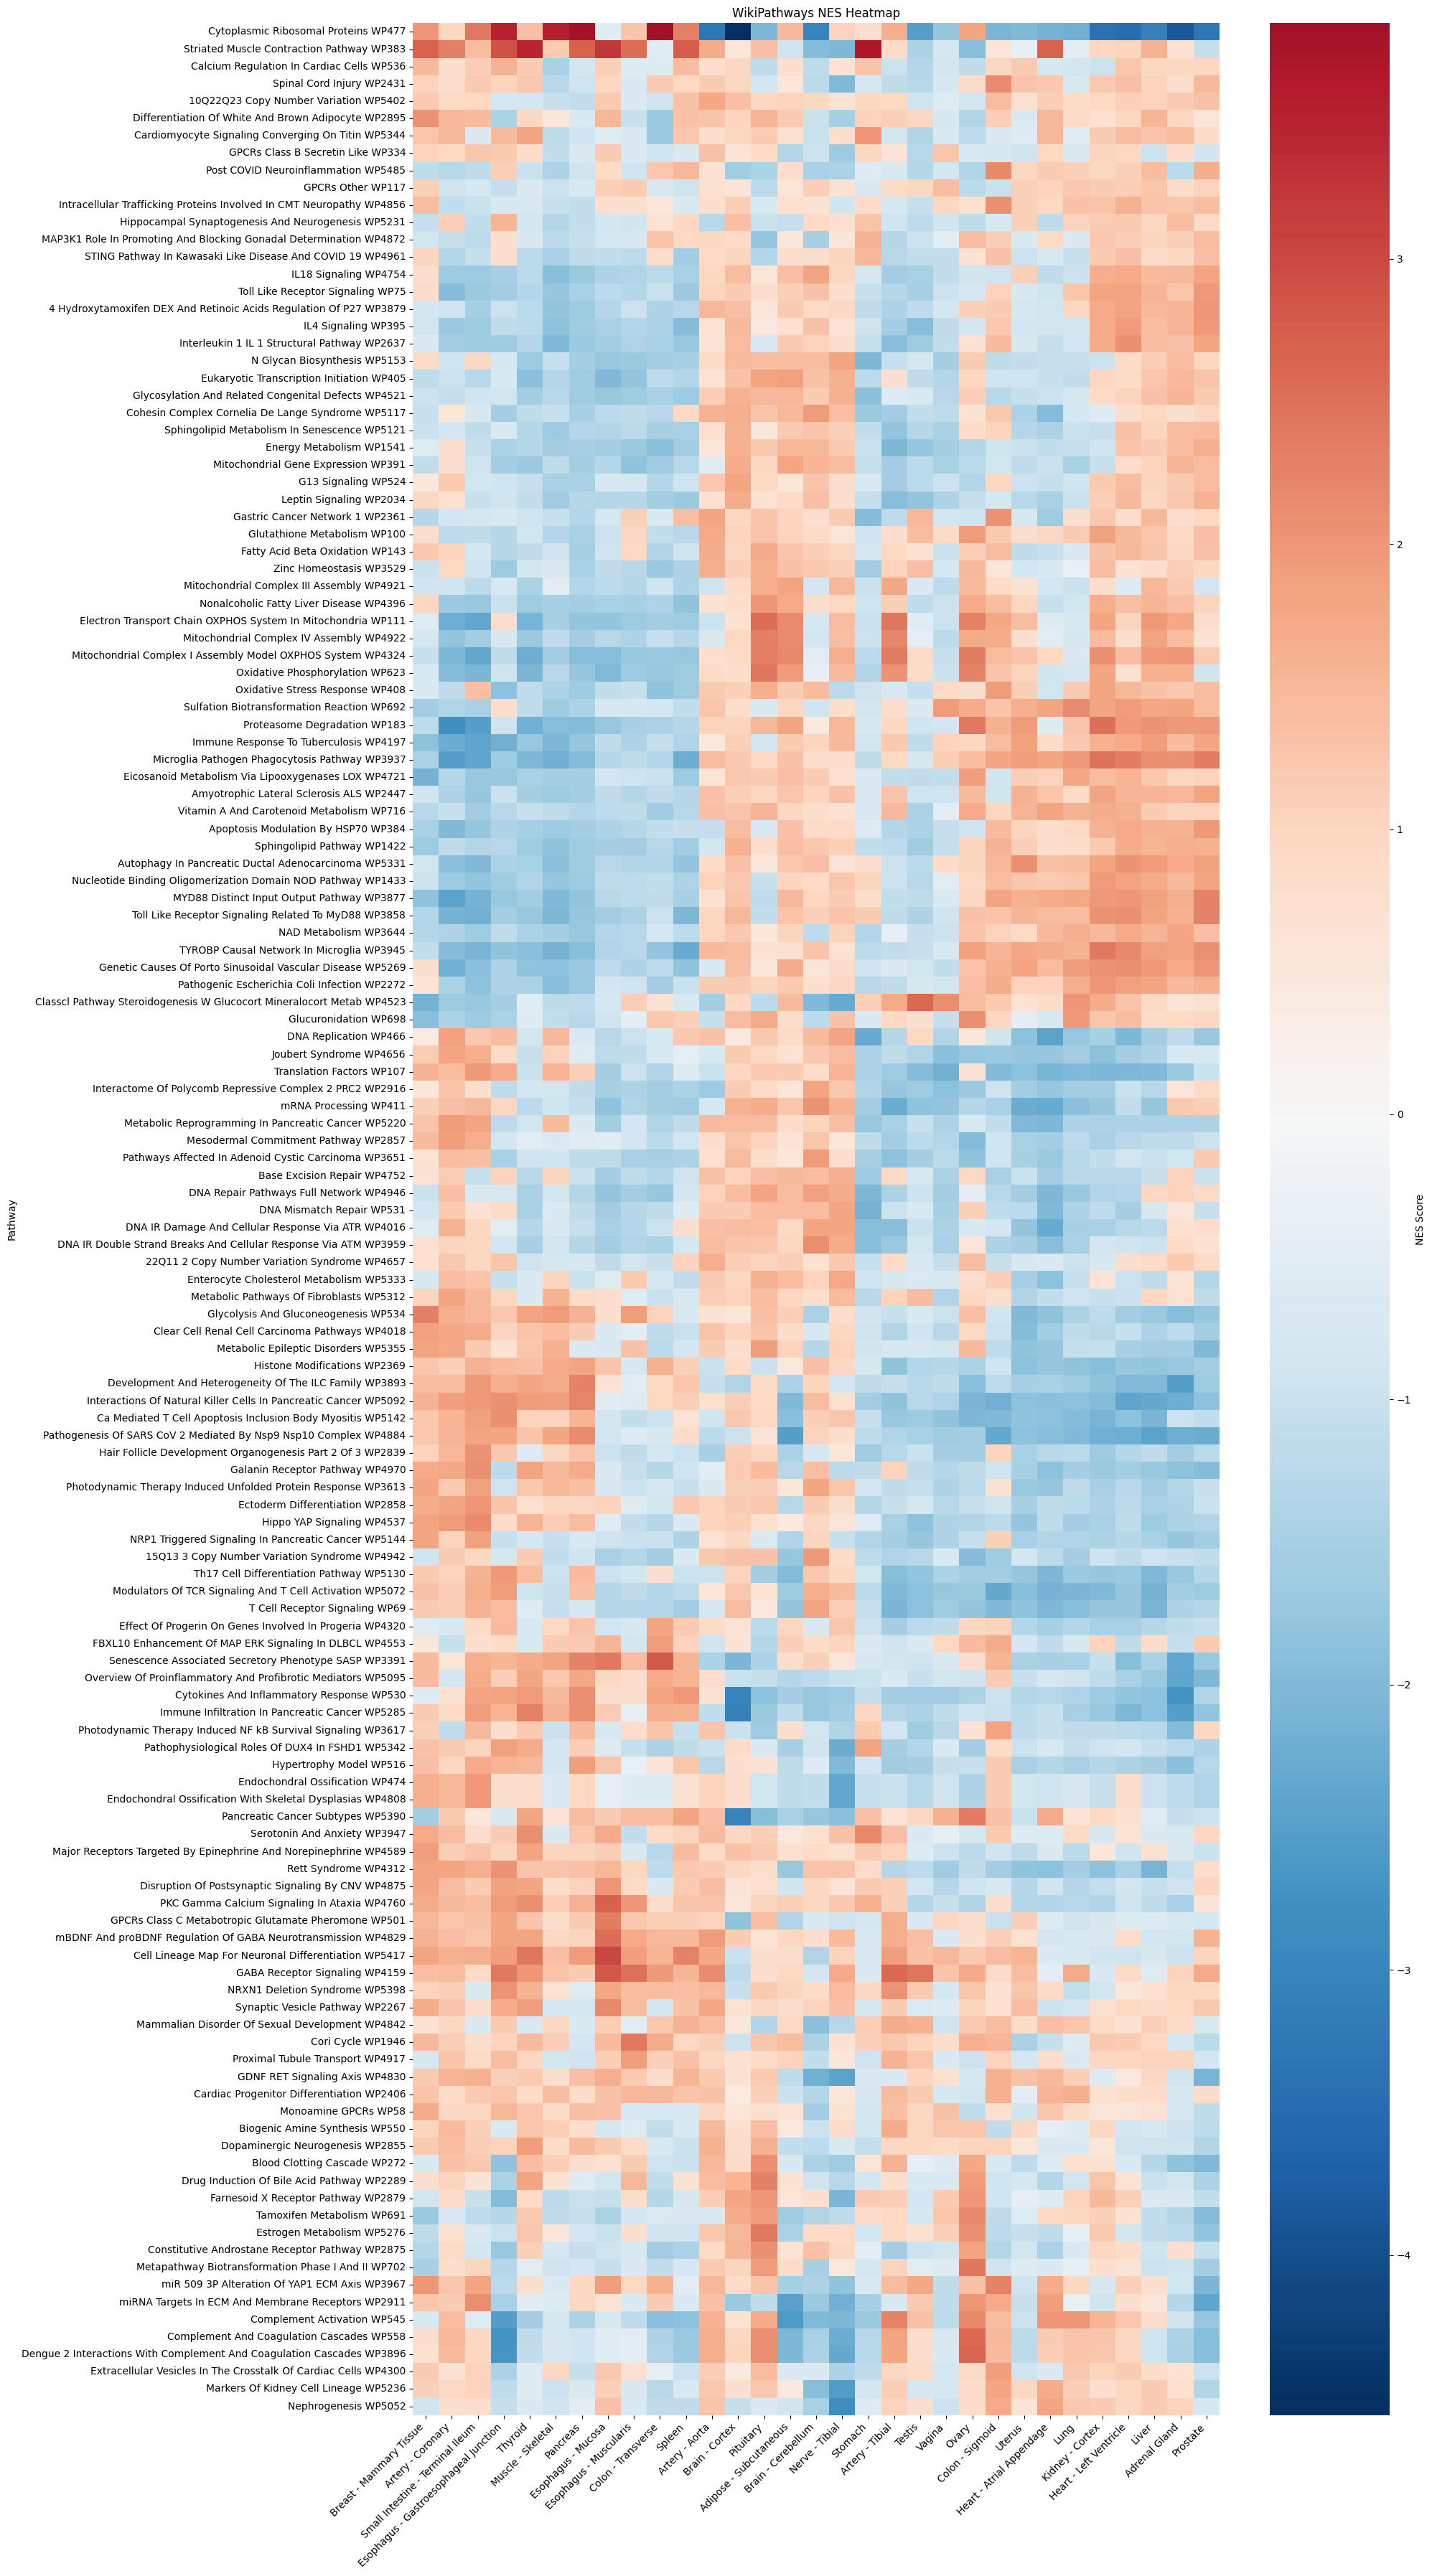

,Breast - Mammary Tissue,Artery - Coronary,Small Intestine - Terminal Ileum,Esophagus - Gastroesophageal Junction,Thyroid,Muscle - Skeletal,Pancreas,Esophagus - Mucosa,Esophagus - Muscularis,Colon - Transverse,...,Ovary,Colon - Sigmoid,Uterus,Heart - Atrial Appendage,Lung,Kidney - Cortex,Heart - Left Ventricle,Liver,Adrenal Gland,Prostate
Pathway,,,,,,,,,,,,,,,,,,,,,
Cytoplasmic Ribosomal Proteins WP477,2.003688,0.985729,2.407927,3.485400,1.368441,3.505581,3.811397,-0.551594,1.280980,3.826121,...,1.764708,-2.073057,-2.022886,-2.148089,-2.199891,-3.386812,-3.448112,-3.073536,-3.859144,-3.293527
Striated Muscle Contraction Pathway WP383,2.683929,2.298337,1.410516,2.891459,3.449412,1.176338,2.676831,3.214562,2.515953,-0.538289,...,-1.916995,0.609461,-0.402436,2.683505,-0.477723,0.969735,1.013136,1.567204,0.693897,-1.076131
Calcium Regulation In Cardiac Cells WP536,1.494009,0.783524,1.113225,1.566366,1.147850,-1.465085,-0.828448,1.083583,-0.622354,-0.603376,...,-1.123979,0.978468,1.174648,-0.807504,-0.843943,-0.959769,1.251446,0.970559,0.954466,0.956659
Spinal Cord Injury WP2431,1.046864,0.840929,1.204908,1.026562,1.209978,-1.256379,-0.947492,0.973297,-0.679014,1.151899,...,0.858096,2.136953,1.285126,1.211531,-0.706063,1.193164,1.341841,1.061375,0.808163,1.482494
10Q22Q23 Copy Number Variation WP5402,1.185566,0.897571,0.919760,-0.808248,-0.830494,-1.025936,-1.097686,1.179495,-0.665904,-0.952219,...,-0.873962,1.400693,0.738507,1.138870,0.863375,0.917430,1.101216,1.060152,1.193271,1.335685
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Complement And Coagulation Cascades WP558,0.750291,1.506003,0.993335,-2.703192,-1.156095,-0.780641,-0.923821,-0.532657,-0.492022,-1.398031,...,2.591153,1.476530,-1.228206,1.164481,1.281104,1.273439,0.992102,-0.902670,-1.438865,-1.917030
Dengue 2 Interactions With Complement And Coagulation Cascades WP3896,0.716676,1.466290,0.993567,-2.674759,-1.097932,-0.761601,-0.921317,-0.545435,-0.470225,-1.379827,...,2.623185,1.437626,-1.245300,1.136974,1.277806,1.262045,0.965249,-0.949001,-1.472219,-1.936518
Extracellular Vesicles In The Crosstalk Of Cardiac Cells WP4300,1.162032,0.693404,1.058909,-1.424583,-0.584606,0.988640,-1.074587,1.226102,0.742097,-0.443779,...,0.895198,1.908478,-0.930733,-0.689126,1.231319,1.018501,1.162364,0.847503,0.680104,-0.977782


In [ ]:
heat_map_Wiki()

Go Pathways

In [ ]:
def heat_map_Go():
    import gseapy as gp
    import pandas as pd
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Read delta data to get tissue names
    delta_data = pd.read_csv('/shares/sinha/epallapotu/blood_expression_project/all_tissues_delta_scores.tsv', sep='\t')
    unique_tissues = delta_data["tissue"].unique()

    # Create a dictionary to store NES scores
    combined_nes_scores = {}

    for tissue in unique_tissues:
        file_path = f"/shares/sinha/epallapotu/blood_expression_project/{tissue}_analysis_results/{tissue}_correlation_results.csv"
        df = pd.read_csv(file_path)

        df_new = df.drop(['P_value', 'Name'], axis=1)
        df_new = df_new.dropna(subset=['Pearson', 'Description']).reset_index(drop=True)
        df_sorted = df_new.sort_values(by='Pearson', ascending=False).copy()
        df_sorted['Pearson'] = pd.to_numeric(df_sorted['Pearson'], errors='coerce')
        df_sorted = df_sorted.dropna(subset=['Pearson', 'Description'])
        df_sorted['Pearson'] = df_sorted['Pearson'].astype(np.float64)
        df_sorted.rename(columns={'Pearson': 'score', 'Description': 'gene_name'}, inplace=True)
        df_sorted['gene_name'] = df_sorted['gene_name'].str.upper()
        rnk_df = df_sorted[['gene_name', 'score']]

        enrichment_results = gp.prerank(
            rnk=rnk_df,
            gene_sets="GO_Biological_Process_2021",
            outdir=None,
            seed=42
        )
        enrichment_df = pd.DataFrame(enrichment_results.results).transpose()

        # Get NES scores
        nes_scores = pd.to_numeric(enrichment_df['nes'], errors='coerce')
        combined_nes_scores[tissue] = nes_scores

 # Combine all NES scores into a single DataFrame
    heatmap_df = pd.DataFrame(combined_nes_scores)

    # Optional: sort rows and/or columns if needed
    heatmap_df = heatmap_df.sort_index()

    from scipy.cluster.hierarchy import linkage, leaves_list
    from scipy.spatial.distance import pdist

    # Cluster rows (pathways)
    row_linkage = linkage(pdist(heatmap_df.fillna(0)), method='average')
    row_order = leaves_list(row_linkage)

    # Cluster columns (tissues)
    col_linkage = linkage(pdist(heatmap_df.fillna(0).T), method='average')
    col_order = leaves_list(col_linkage)

    # Reorder heatmap_df
    ordered_df = heatmap_df.iloc[row_order, :].iloc[:, col_order]

    # Plot heatmap
    plt.figure(figsize=(12, 36))
    sns.heatmap(
        ordered_df,
        cmap='RdBu_r',
        center=0,
        annot=False,
        xticklabels=True,
        yticklabels=True,
        cbar_kws={'label': 'NES Score'}
    )
    plt.xticks(rotation=45, ha='right')
    plt.title("GO Biological Process NES Heatmap")
    plt.tight_layout()
    plt.show()


In [ ]:
heat_map_Go()